# Step 10 - Presentation Figures

Generate clean figures for the final presentation.


In [2]:
import json
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().resolve().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.config import AIRPORT_TIMEZONES
from src.data import load_flights, load_weather
from src.features import add_scheduled_departure_utc, prepare_flights, prepare_weather_features
from src.weather_join import join_weather_to_flights

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 140
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["xtick.labelsize"] = 11
plt.rcParams["ytick.labelsize"] = 11

figure_dir = Path("../outputs/figures/presentation_assets")
figure_dir.mkdir(parents=True, exist_ok=True)

def save_current(name):
    path = figure_dir / name
    plt.tight_layout()
    plt.savefig(path, dpi=220, bbox_inches="tight")
    return path

airline_labels = {
    "WN": "Southwest",
    "AA": "American",
    "DL": "Delta",
    "UA": "United",
    "B6": "JetBlue",
    "OO": "SkyWest",
}

main_palette = ["#4C78A8", "#F58518", "#54A24B", "#E45756", "#72B7B2", "#B279A2"]


## Class Balance


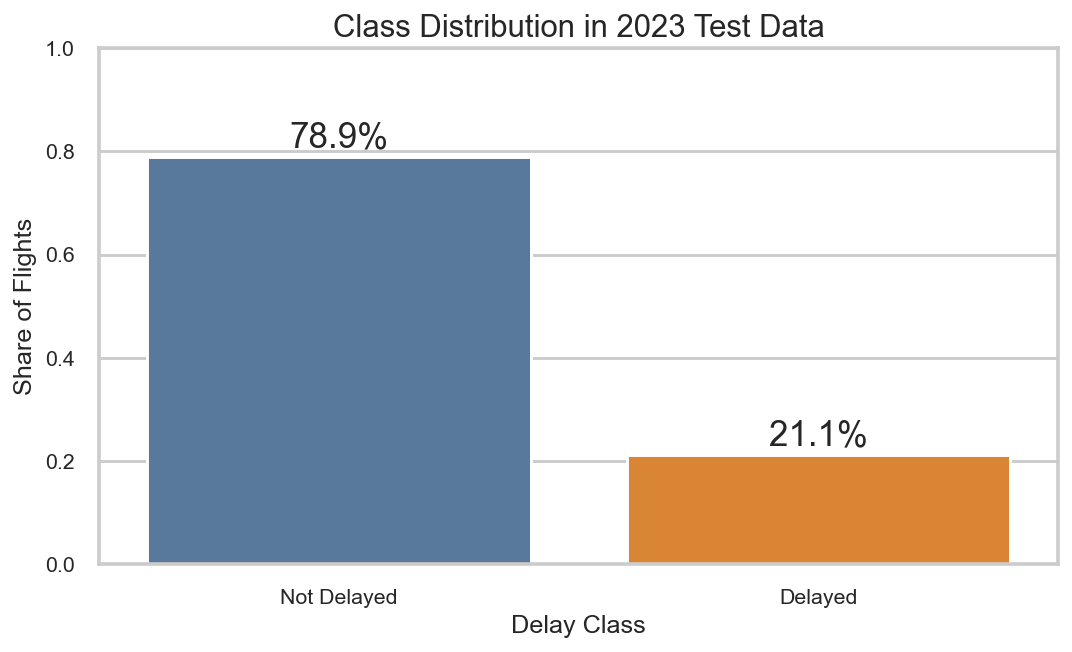

In [3]:
summary = json.loads(Path("../outputs/reports/05_rf_final/dataset_summary.json").read_text(encoding="utf-8"))
test_delay_rate = summary["test_delay_rate"]
class_balance_df = pd.DataFrame({
    "Delay Class": ["Not Delayed", "Delayed"],
    "Share of Flights": [1 - test_delay_rate, test_delay_rate],
})

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=class_balance_df, x="Delay Class", y="Share of Flights", hue="Delay Class", dodge=False, palette=["#4C78A8", "#F58518"], ax=ax, legend=False)
ax.set_title("Class Distribution in 2023 Test Data")
ax.set_xlabel("Delay Class")
ax.set_ylabel("Share of Flights")
ax.set_ylim(0, 1)
for i, v in enumerate(class_balance_df["Share of Flights"]):
    ax.text(i, v + 0.02, f"{v:.1%}", ha="center")
save_current("01_class_balance_2023_test.png")
plt.show()


## Weather Vs No Weather


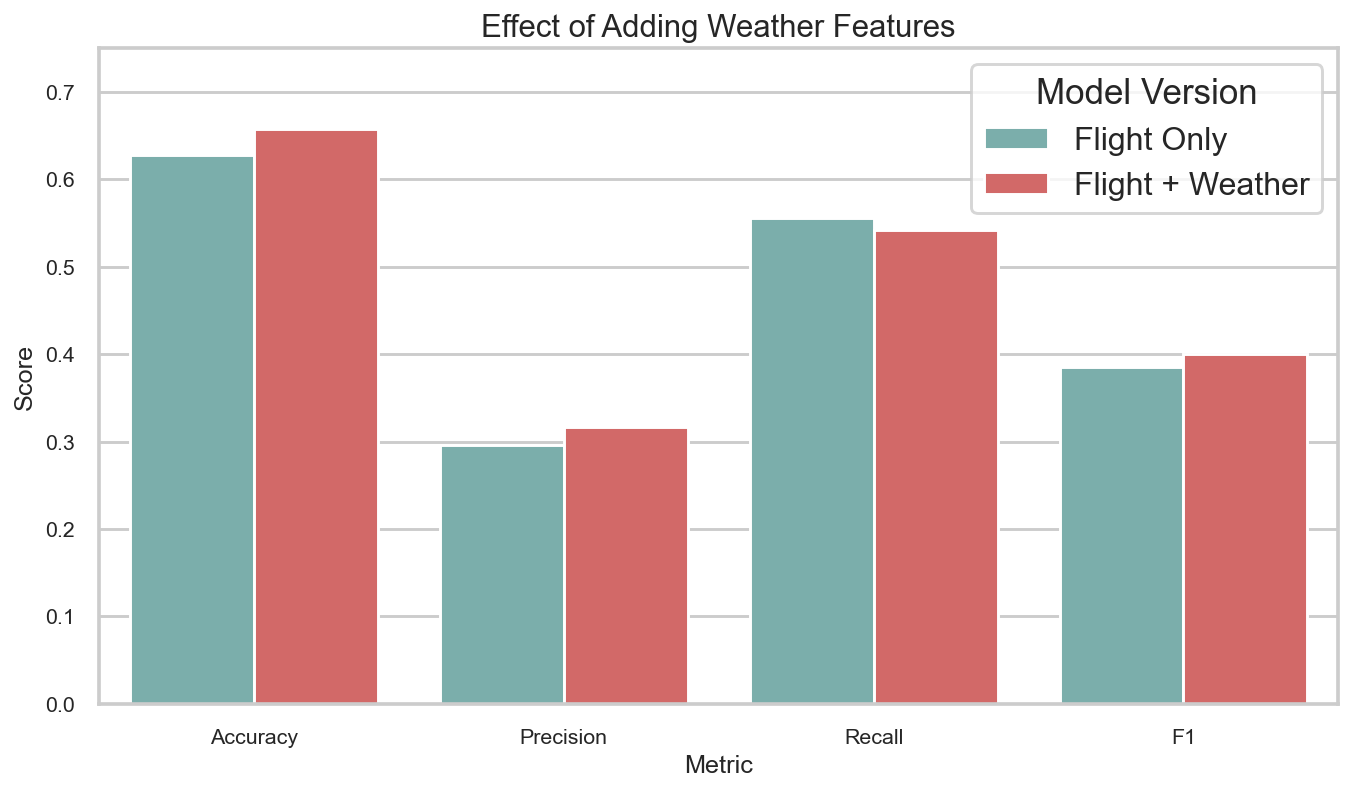

In [4]:
weather_compare = pd.DataFrame([
    {"Model Version": "Flight Only", "Accuracy": 0.627776, "Precision": 0.295647, "Recall": 0.555584, "F1": 0.385928},
    {"Model Version": "Flight + Weather", "Accuracy": 0.657390, "Precision": 0.316767, "Recall": 0.542289, "F1": 0.399925},
])
weather_long = weather_compare.melt(id_vars="Model Version", var_name="Metric", value_name="Score")

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=weather_long, x="Metric", y="Score", hue="Model Version", palette=["#72B7B2", "#E45756"], ax=ax)
ax.set_title("Effect of Adding Weather Features")
ax.set_xlabel("Metric")
ax.set_ylabel("Score")
ax.set_ylim(0, 0.75)
ax.legend(title="Model Version")
save_current("02_weather_vs_no_weather.png")
plt.show()


## Weather Severity Sample


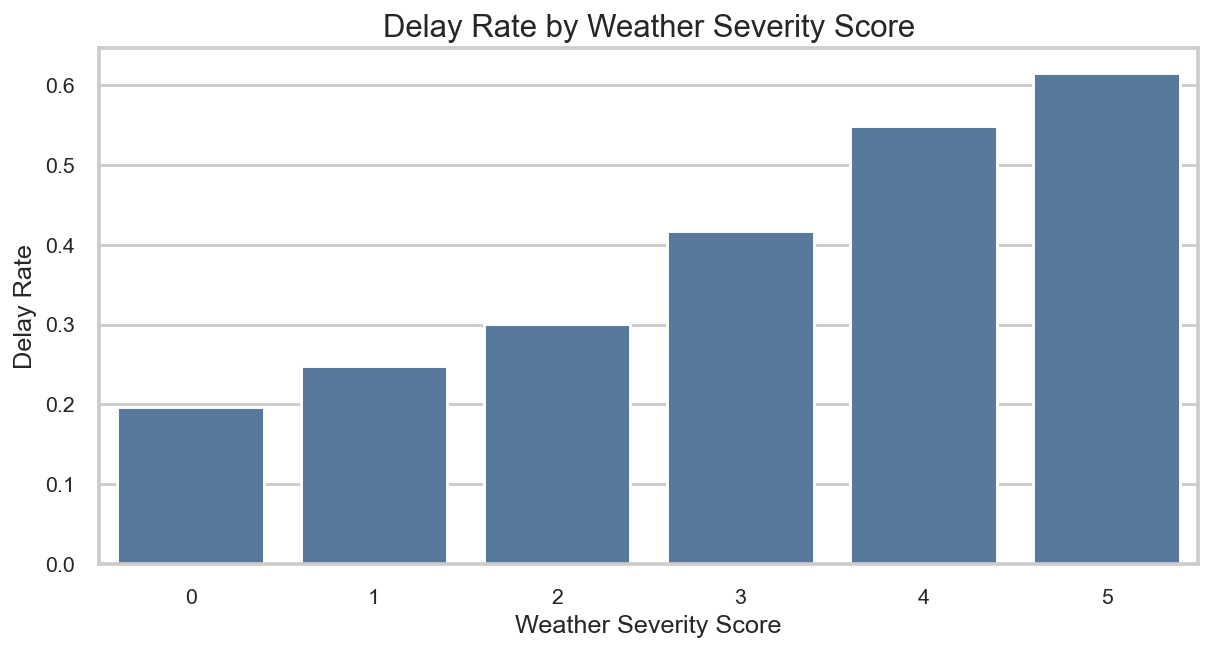

In [5]:
SAMPLE_SIZE = 200_000
flights = prepare_flights(load_flights(), sample_size=SAMPLE_SIZE, random_state=42)
weather = load_weather()
flights = flights[flights["Origin"].isin(sorted(weather["station"].dropna().unique()))].copy()
flights = add_scheduled_departure_utc(flights, AIRPORT_TIMEZONES)
flights = flights.dropna(subset=["scheduled_departure_utc"]).copy()
sample_df = join_weather_to_flights(flights, weather, tolerance_hours=2)
sample_df = prepare_weather_features(sample_df)
sample_df["very_high_wind"] = (sample_df["sknt"] >= 25).astype(int)
sample_df["freezing_temp"] = (sample_df["tmpf"] <= 32).astype(int)
sample_df["low_pressure"] = (sample_df["alti"] < 29.7).astype(int)
sample_df["weather_severity_score"] = sample_df[["has_precip", "low_visibility", "high_wind", "very_high_wind", "freezing_temp", "low_pressure"]].sum(axis=1)
sample_df["Reporting_Airline_Label"] = sample_df["Reporting_Airline"].map(airline_labels).fillna(sample_df["Reporting_Airline"])
sample_df["time_of_day_bin"] = sample_df["time_of_day_bin"].astype(str)
severity_plot = sample_df.groupby("weather_severity_score")["Delay"].mean().reset_index()

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=severity_plot, x="weather_severity_score", y="Delay", color="#4C78A8", ax=ax)
ax.set_title("Delay Rate by Weather Severity Score")
ax.set_xlabel("Weather Severity Score")
ax.set_ylabel("Delay Rate")
save_current("03_weather_severity_score.png")
plt.show()


## Feature Group Ablation


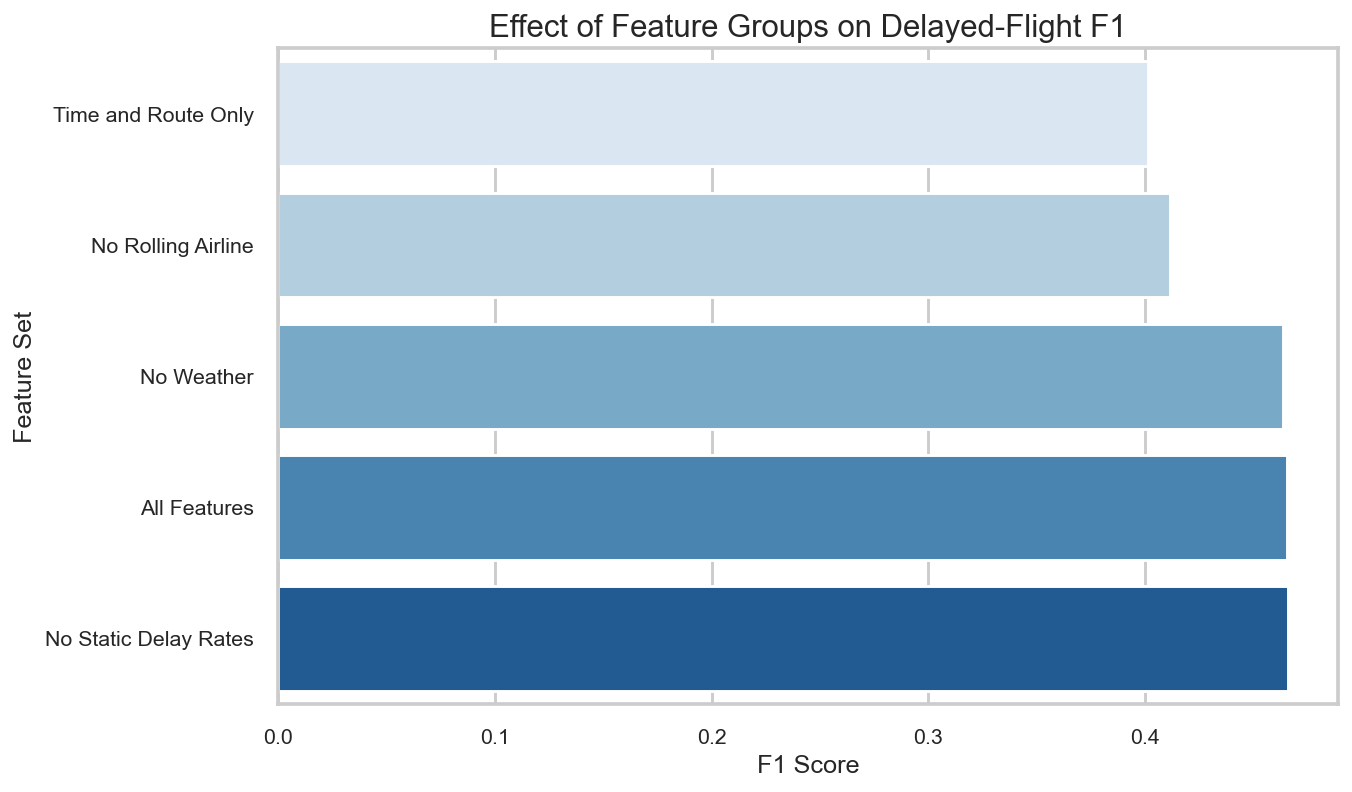

In [6]:
ablation_df = pd.DataFrame([
    {"Feature Set": "No Static Delay Rates", "F1": 0.465898},
    {"Feature Set": "All Features", "F1": 0.465513},
    {"Feature Set": "No Weather", "F1": 0.463563},
    {"Feature Set": "No Rolling Airline", "F1": 0.411398},
    {"Feature Set": "Time and Route Only", "F1": 0.401512},
]).sort_values("F1", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=ablation_df, y="Feature Set", x="F1", hue="Feature Set", dodge=False, palette="Blues", ax=ax, legend=False)
ax.set_title("Effect of Feature Groups on Delayed-Flight F1")
ax.set_xlabel("F1 Score")
ax.set_ylabel("Feature Set")
save_current("04_feature_group_ablation.png")
plt.show()


## Final Metrics


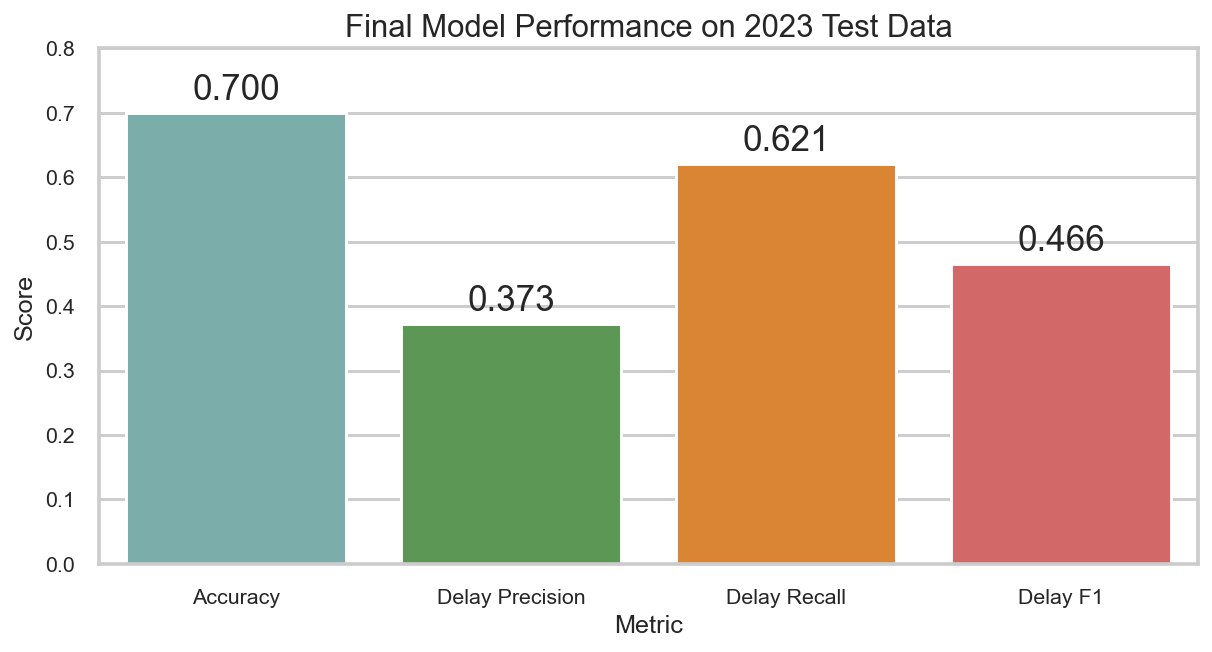

In [7]:
metrics_df = pd.read_csv("../outputs/reports/05_rf_final/metrics.csv")
metrics_plot = pd.DataFrame({
    "Metric": ["Accuracy", "Delay Precision", "Delay Recall", "Delay F1"],
    "Score": [
        metrics_df.loc[0, "accuracy"],
        metrics_df.loc[0, "precision_delay"],
        metrics_df.loc[0, "recall_delay"],
        metrics_df.loc[0, "f1_delay"],
    ],
})

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=metrics_plot, x="Metric", y="Score", hue="Metric", dodge=False, palette=["#72B7B2", "#54A24B", "#F58518", "#E45756"], ax=ax, legend=False)
ax.set_title("Final Model Performance on 2023 Test Data")
ax.set_xlabel("Metric")
ax.set_ylabel("Score")
ax.set_ylim(0, 0.8)
for i, v in enumerate(metrics_plot["Score"]):
    ax.text(i, v + 0.02, f"{v:.3f}", ha="center")
save_current("05_final_metrics.png")
plt.show()


## Final Confusion Matrix


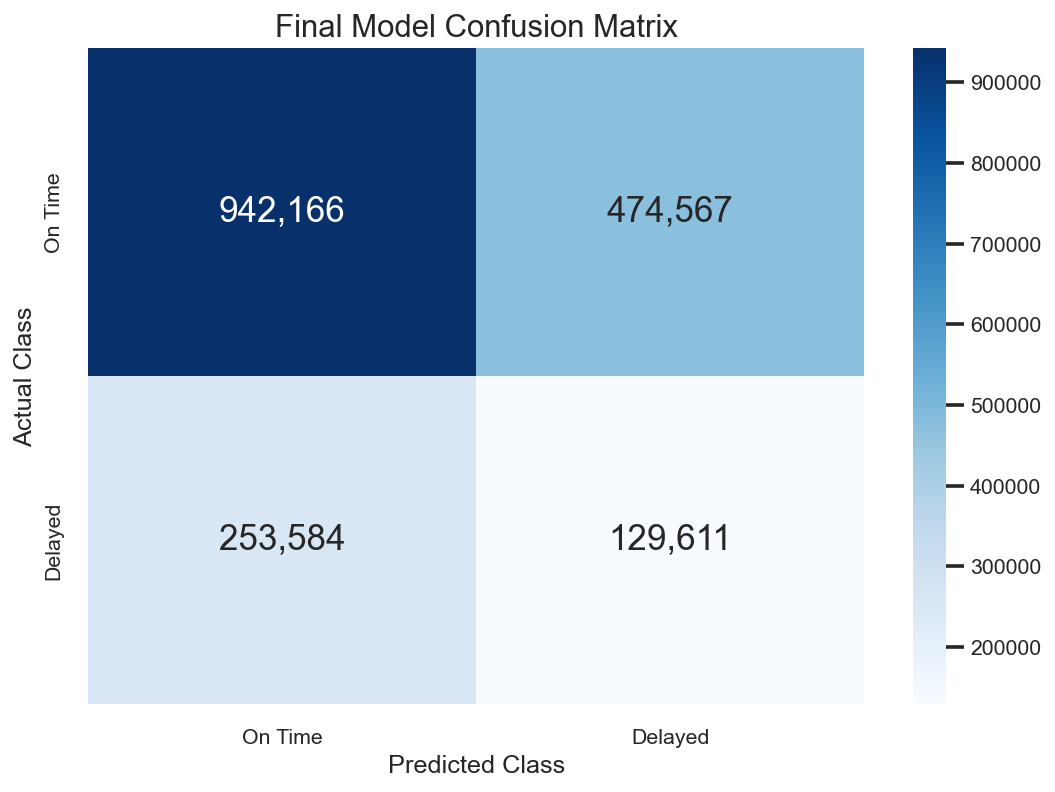

In [8]:
cm = pd.read_csv("../outputs/reports/05_rf_final/confusion_matrix.csv", index_col=0)
cm.index = ["On Time", "Delayed"]
cm.columns = ["On Time", "Delayed"]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt=",", cmap="Blues", cbar=True, ax=ax)
ax.set_title("Final Model Confusion Matrix")
ax.set_xlabel("Predicted Class")
ax.set_ylabel("Actual Class")
save_current("06_final_confusion_matrix.png")
plt.show()


## Top Feature Importance


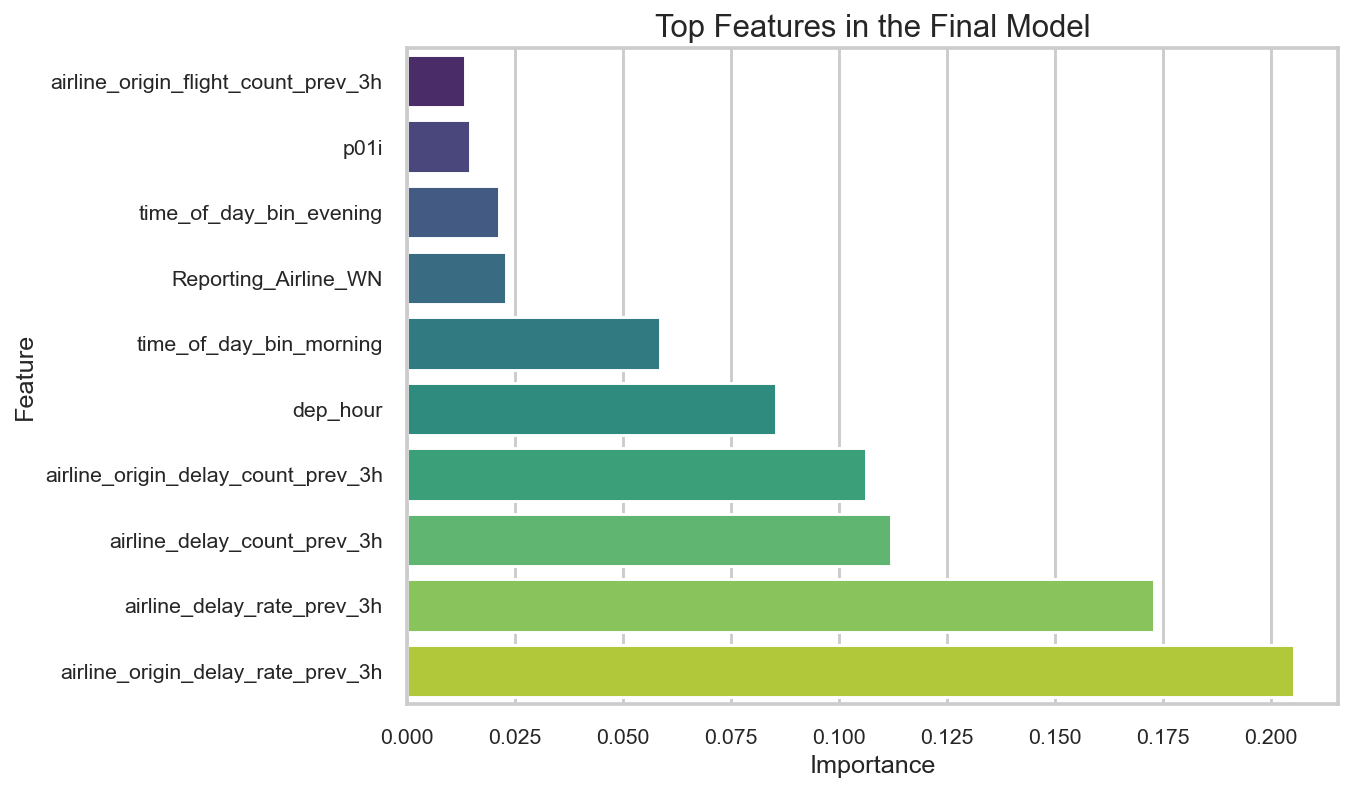

In [9]:
importance_df = pd.read_csv("../outputs/reports/05_rf_final/feature_importance.csv").head(10).copy()
importance_df["feature"] = importance_df["feature"].str.replace("num__", "", regex=False)
importance_df["feature"] = importance_df["feature"].str.replace("cat__", "", regex=False)
importance_df = importance_df.sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=importance_df, y="feature", x="importance", hue="feature", dodge=False, palette="viridis", ax=ax, legend=False)
ax.set_title("Top Features in the Final Model")
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")
save_current("07_final_feature_importance.png")
plt.show()


## Model Progression


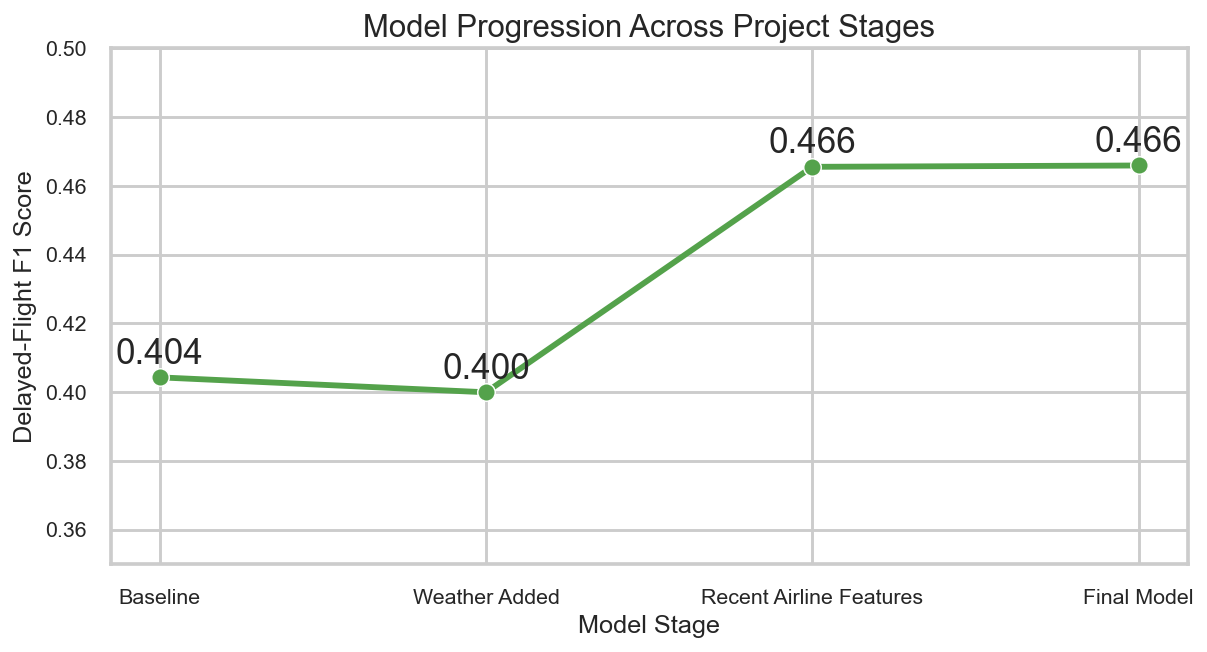

In [10]:
progression_df = pd.DataFrame([
    {"Stage": "Baseline", "F1": 0.404272},
    {"Stage": "Weather Added", "F1": 0.399925},
    {"Stage": "Recent Airline Features", "F1": 0.465513},
    {"Stage": "Final Model", "F1": 0.465898},
])

fig, ax = plt.subplots(figsize=(9, 5))
sns.lineplot(data=progression_df, x="Stage", y="F1", marker="o", linewidth=3, color="#54A24B", ax=ax)
ax.set_title("Model Progression Across Project Stages")
ax.set_xlabel("Model Stage")
ax.set_ylabel("Delayed-Flight F1 Score")
ax.set_ylim(0.35, 0.5)
for i, row in progression_df.iterrows():
    ax.text(i, row["F1"] + 0.004, f"{row['F1']:.3f}", ha="center")
save_current("08_model_progression.png")
plt.show()


## Delay Rate by Time of Day


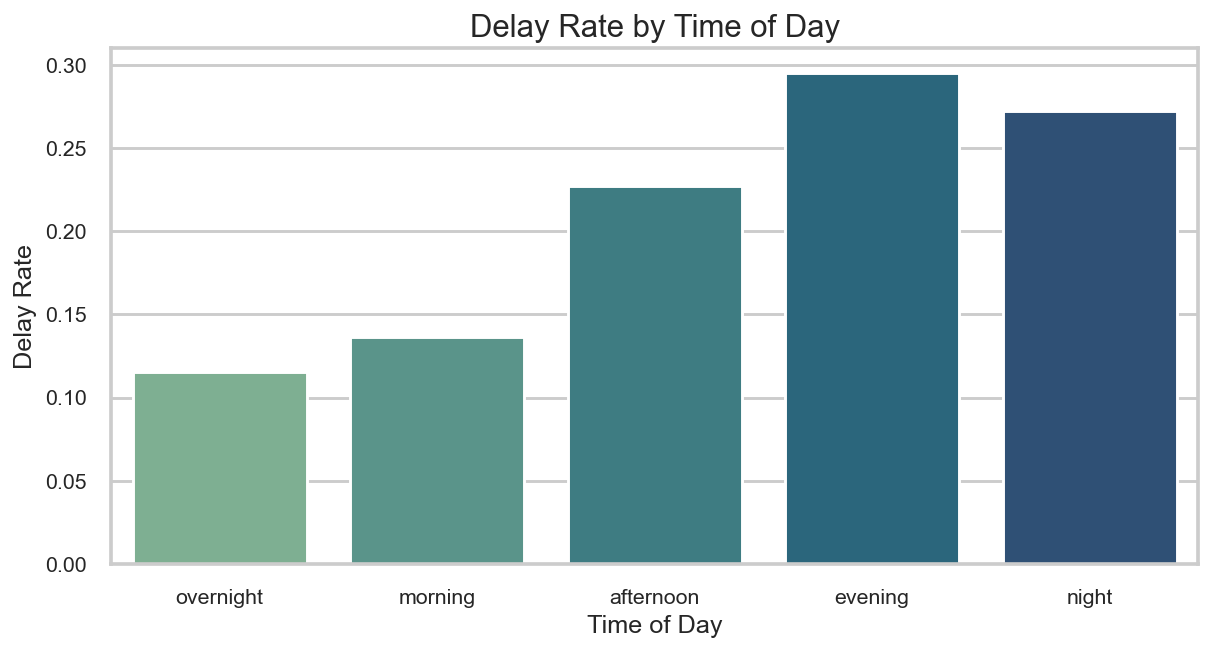

In [11]:
tod_plot = sample_df.groupby("time_of_day_bin", observed=False)["Delay"].mean().reset_index()
tod_order = ["overnight", "morning", "afternoon", "evening", "night"]
tod_plot["time_of_day_bin"] = pd.Categorical(tod_plot["time_of_day_bin"], categories=tod_order, ordered=True)
tod_plot = tod_plot.sort_values("time_of_day_bin")

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=tod_plot, x="time_of_day_bin", y="Delay", hue="time_of_day_bin", dodge=False, palette="crest", ax=ax, legend=False)
ax.set_title("Delay Rate by Time of Day")
ax.set_xlabel("Time of Day")
ax.set_ylabel("Delay Rate")
save_current("09_delay_by_time_of_day.png")
plt.show()


## Delay Rate by Airline


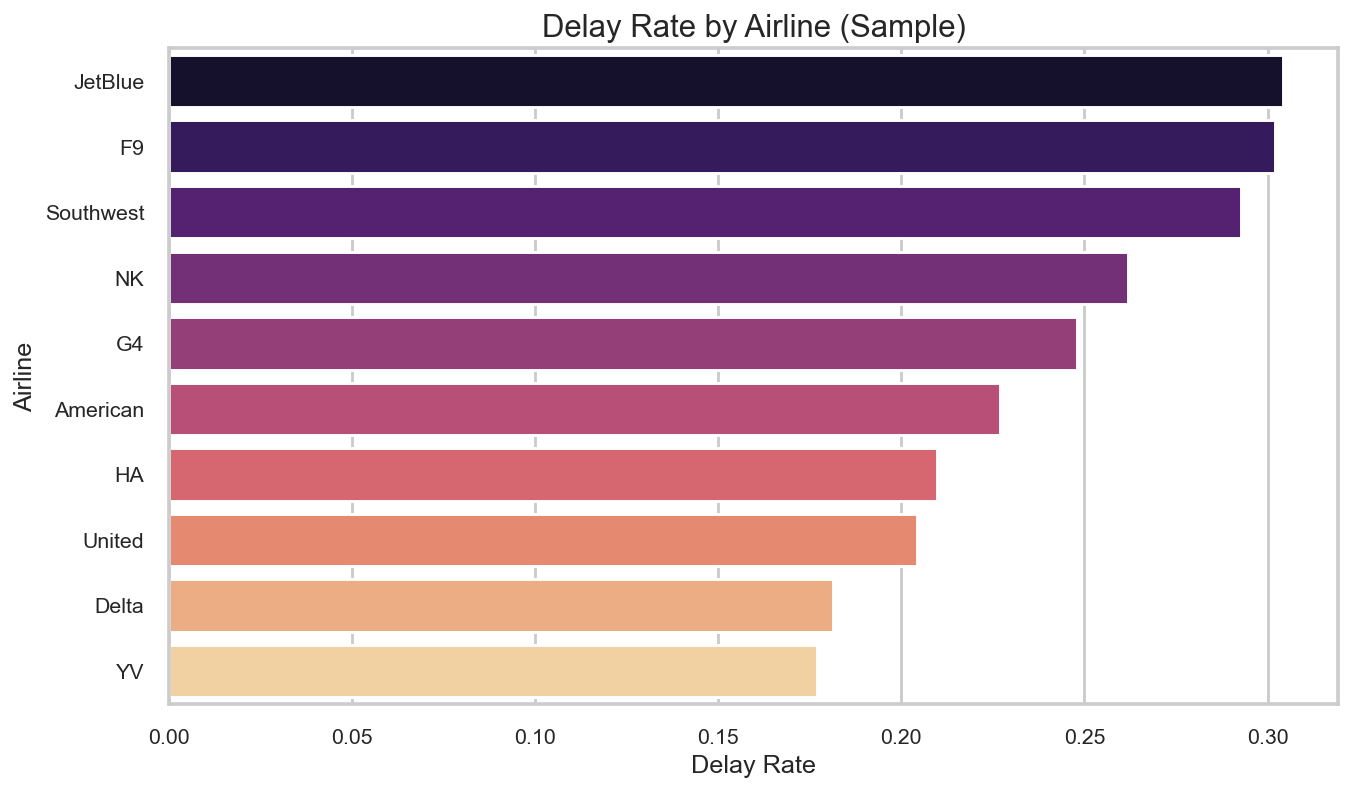

In [12]:
airline_plot = sample_df.groupby("Reporting_Airline_Label")["Delay"].mean().reset_index()
airline_plot = airline_plot.sort_values("Delay", ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=airline_plot, y="Reporting_Airline_Label", x="Delay", hue="Reporting_Airline_Label", dodge=False, palette="magma", ax=ax, legend=False)
ax.set_title("Delay Rate by Airline (Sample)")
ax.set_xlabel("Delay Rate")
ax.set_ylabel("Airline")
save_current("10_delay_by_airline.png")
plt.show()


## Saved Files


In [13]:
sorted(path.name for path in figure_dir.glob("*.png"))


['01_class_balance_2023_test.png',
 '02_weather_vs_no_weather.png',
 '03_weather_severity_score.png',
 '04_feature_group_ablation.png',
 '05_final_metrics.png',
 '06_final_confusion_matrix.png',
 '07_final_feature_importance.png',
 '08_model_progression.png',
 '09_delay_by_time_of_day.png',
 '10_delay_by_airline.png']